# MARDM training curves

Loads `metrics.csv` from an AE and a gen run and plots the standard diagnostics: loss, validation loss, learning rate, throughput, gradient norm.

Set `AE_RUN` / `GEN_RUN` below to match the run directories under `~/rmg-runs/`. If you're running this on your laptop, `rsync` the run dirs over first (only `metrics.csv` is needed for these plots).

Each plot is saved to `notebooks/figures/` as a PDF (vector, slide-ready) and a PNG (for quick previews).

In [7]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

RUNS_ROOT = Path.home() / "rmg-runs"
AE_RUN    = "mardm-ae-9813"
GEN_RUN   = "mardm-gen-9817"

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "savefig.bbox": "tight", "pdf.fonttype": 42})

def save_fig(fig, stem):
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"{stem}.{ext}")

In [2]:
def load_metrics(path):
    # Logger appends columns lazily (ae/val_l1, gen/val_loss) the on-disk
    # header doesn't list — so naive pd.read_csv chokes on the schema growth.
    lines = Path(path).read_text().splitlines()
    header = lines[0].split(",")
    rows = [l.split(",") for l in lines[1:] if l]
    max_cols = max(len(header), max((len(r) for r in rows), default=0))
    while len(header) < max_cols:
        header.append(f"_extra_{len(header)}")
    padded = [r + [""] * (max_cols - len(r)) for r in rows]
    df = pd.DataFrame(padded, columns=header).apply(pd.to_numeric, errors="coerce")
    return df


def split_train_val(df, train_col, val_label):
    train = df[df[train_col].notna()].copy()
    extra = [c for c in df.columns if c.startswith("_extra_")]
    if extra:
        val = df[df[extra[0]].notna()][["step", extra[0]]].rename(columns={extra[0]: val_label})
    else:
        val = pd.DataFrame(columns=["step", val_label])
    return train, val

## AE (stage 1)

In [3]:
ae_df = load_metrics(RUNS_ROOT / AE_RUN / "metrics.csv")
ae_train, ae_val = split_train_val(ae_df, "ae/l1", "ae/val_l1")

print(f"AE rows: train={len(ae_train)} val={len(ae_val)}")
print(f"final train l1: {ae_train['ae/l1'].iloc[-1]:.4f}")
if not ae_val.empty:
    print(f"final val l1:   {ae_val['ae/val_l1'].iloc[-1]:.4f}")
    print(f"train/val gap:  {ae_val['ae/val_l1'].iloc[-1] / ae_train['ae/l1'].iloc[-1]:.2f}x")

AE rows: train=241 val=6
final train l1: 0.1098
final val l1:   0.5186
train/val gap:  4.72x


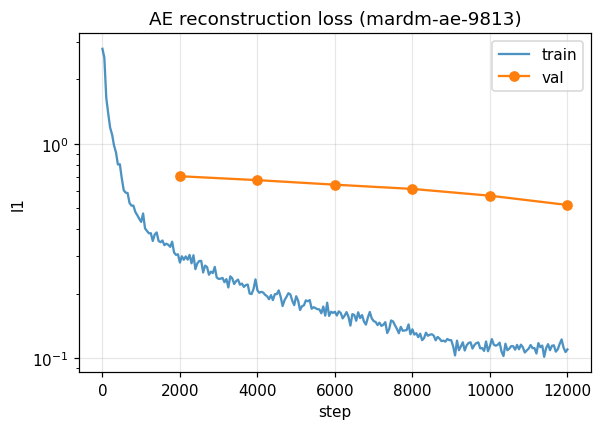

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ae_train["step"], ae_train["ae/l1"], label="train", alpha=0.8)
if not ae_val.empty:
    ax.plot(ae_val["step"], ae_val["ae/val_l1"], "o-", label="val", color="C1")
ax.set(xlabel="step", ylabel="l1", title=f"AE reconstruction loss ({AE_RUN})", yscale="log")
ax.legend()
save_fig(fig, "ae_loss")
plt.show()

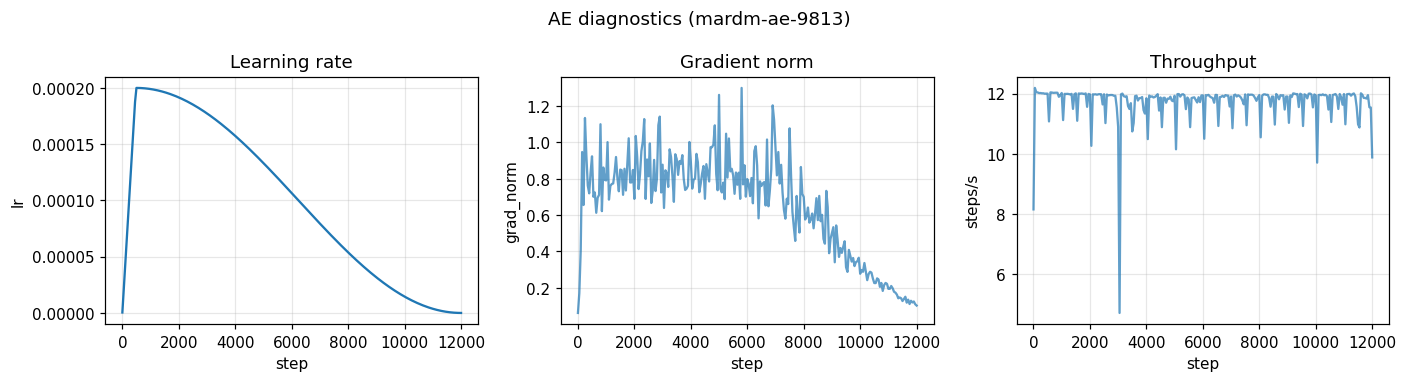

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
axes[0].plot(ae_train["step"], ae_train["lr"])
axes[0].set(xlabel="step", ylabel="lr", title="Learning rate")
axes[1].plot(ae_train["step"], ae_train["grad_norm"], alpha=0.7)
axes[1].set(xlabel="step", ylabel="grad_norm", title="Gradient norm")
axes[2].plot(ae_train["step"], ae_train["steps_per_s"], alpha=0.7)
axes[2].set(xlabel="step", ylabel="steps/s", title="Throughput")
fig.suptitle(f"AE diagnostics ({AE_RUN})")
plt.tight_layout()
save_fig(fig, "ae_diagnostics")
plt.show()

## Gen (stage 2)

In [8]:
gen_df = load_metrics(RUNS_ROOT / GEN_RUN / "metrics.csv")
gen_train, gen_val = split_train_val(gen_df, "gen/loss", "gen/val_loss")

print(f"gen rows: train={len(gen_train)} val={len(gen_val)}")
print(f"final train loss: {gen_train['gen/loss'].iloc[-1]:.4f}")
if not gen_val.empty:
    print(f"final val loss:   {gen_val['gen/val_loss'].iloc[-1]:.4f}")
    print(f"train/val gap:    {gen_val['gen/val_loss'].iloc[-1] / gen_train['gen/loss'].iloc[-1]:.2f}x")

gen rows: train=2001 val=50
final train loss: 0.0580
final val loss:   0.0556
train/val gap:    0.96x


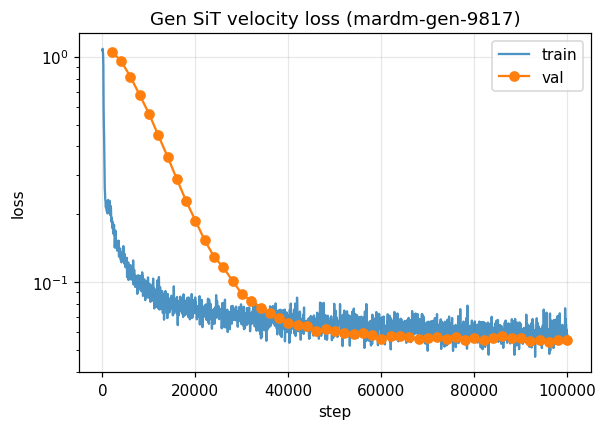

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(gen_train["step"], gen_train["gen/loss"], label="train", alpha=0.8)
if not gen_val.empty:
    ax.plot(gen_val["step"], gen_val["gen/val_loss"], "o-", label="val", color="C1")
ax.set(xlabel="step", ylabel="loss", title=f"Gen SiT velocity loss ({GEN_RUN})", yscale="log")
ax.legend()
save_fig(fig, "gen_loss")
plt.show()

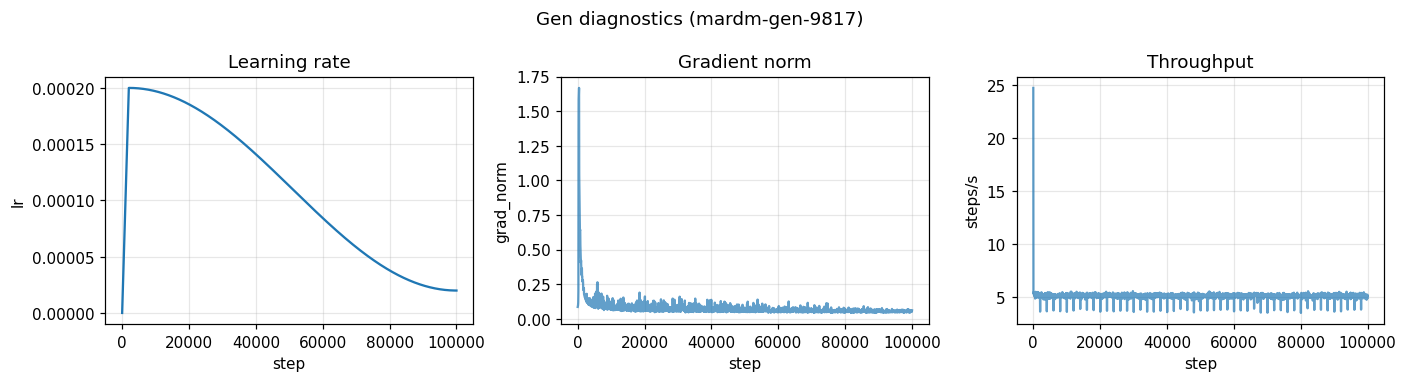

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
axes[0].plot(gen_train["step"], gen_train["lr"])
axes[0].set(xlabel="step", ylabel="lr", title="Learning rate")
axes[1].plot(gen_train["step"], gen_train["grad_norm"], alpha=0.7)
axes[1].set(xlabel="step", ylabel="grad_norm", title="Gradient norm")
axes[2].plot(gen_train["step"], gen_train["steps_per_s"], alpha=0.7)
axes[2].set(xlabel="step", ylabel="steps/s", title="Throughput")
fig.suptitle(f"Gen diagnostics ({GEN_RUN})")
plt.tight_layout()
save_fig(fig, "gen_diagnostics")
plt.show()

## Summary

In [11]:
def summary(name, train, val, loss_col, val_col):
    return {
        "run": name,
        "steps": int(train["step"].iloc[-1]),
        "final_train": round(float(train[loss_col].iloc[-1]), 4),
        "final_val": round(float(val[val_col].iloc[-1]), 4) if not val.empty else None,
        "steady_steps_per_s": round(float(train["steps_per_s"].iloc[10:].mean()), 2),
    }

summary_df = pd.DataFrame([
    summary(AE_RUN,  ae_train,  ae_val,  "ae/l1",   "ae/val_l1"),
    summary(GEN_RUN, gen_train, gen_val, "gen/loss", "gen/val_loss"),
])
summary_df.to_csv(FIG_DIR / "summary.csv", index=False)
summary_df

,run,steps,final_train,final_val,steady_steps_per_s
0,mardm-ae-9813,12000,0.1098,0.5186,11.73
1,mardm-gen-9817,100000,0.0580,0.0556,5.10
